In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline


In [4]:
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
np.hstack([y,-y])# stack y and -y to get full circle
np.hstack([x,-x])

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [5]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
np.hstack([y1,-y1])
np.hstack([x1,-x1])

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

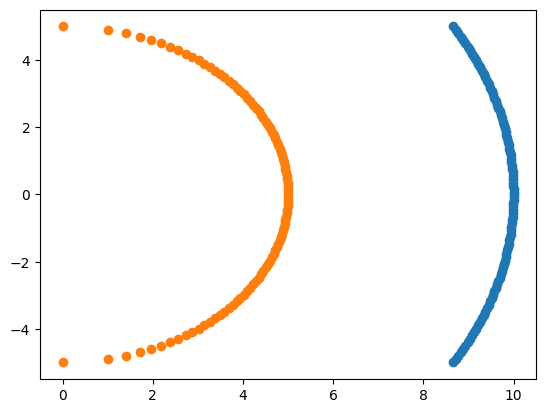

In [6]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [7]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0

df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1

df=pd.concat([df1,df2],ignore_index=True)
print(df.head(5))
df.tail(5)  

         X1       X2  Y
0  8.660254 -5.00000  0
1  8.717792 -4.89899  0
2  8.773790 -4.79798  0
3  8.828277 -4.69697  0
4  8.881281 -4.59596  0


,X1,X2,Y
195,1.969049,4.59596,1
196,1.714198,4.69697,1
197,1.406908,4.79798,1
198,0.999949,4.89899,1
199,0.000000,5.00000,1


In [8]:
x=df.iloc[:, :2]
y=df.Y


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# USING THE FORMULA OF POLYNOMIAL KERNEL
- TO CONVERT THIS CIRCLE TO A 3D FIGURE AND HENCE GET IT IN A STRAIGHT LINE
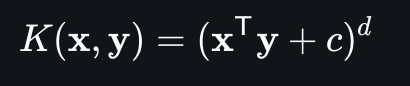

1. polynomial kernek me kuch nahi kia bas 3 column aur add krdiye x1^2 
2. x2^2 and x1*x2 (x1_x2)

In [10]:
df['X1_square']=df['X1']**2
df['X2_square']=df['X2']**2
df['X1_X2']=(df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_square,X2_square,X1_X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [11]:
X=df[['X1','X2','X1_square','X2_square','X1_X2']]
Y=df['Y']

In [12]:
y

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 200, dtype: int64

In [13]:
df.columns

Index(['X1', 'X2', 'Y', 'X1_square', 'X2_square', 'X1_X2'], dtype='object')

In [14]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.scatter_3d(df, x='X1', y='X2', z='X1_square', color='Y')
fig.show()


In [15]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.scatter_3d(df, x='X1_square', y='X2_square', z='X1_X2', color='Y')
fig.show()


In [16]:
from sklearn.svm import SVC 
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
classifier=SVC(kernel='linear')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[21  0]
 [ 0 19]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

1.0


- agar main directly poly use karu... to ye 3 feature jo naye bnaye ye nahi bnane pdenge
- ye poly khud bana lega


In [17]:
classifier=SVC(kernel='poly')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[21  0]
 [ 0 19]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

1.0


# How does rbf fom the best plane.
- it does from a hyberbolical curve which is cut by plane in 2 halve.
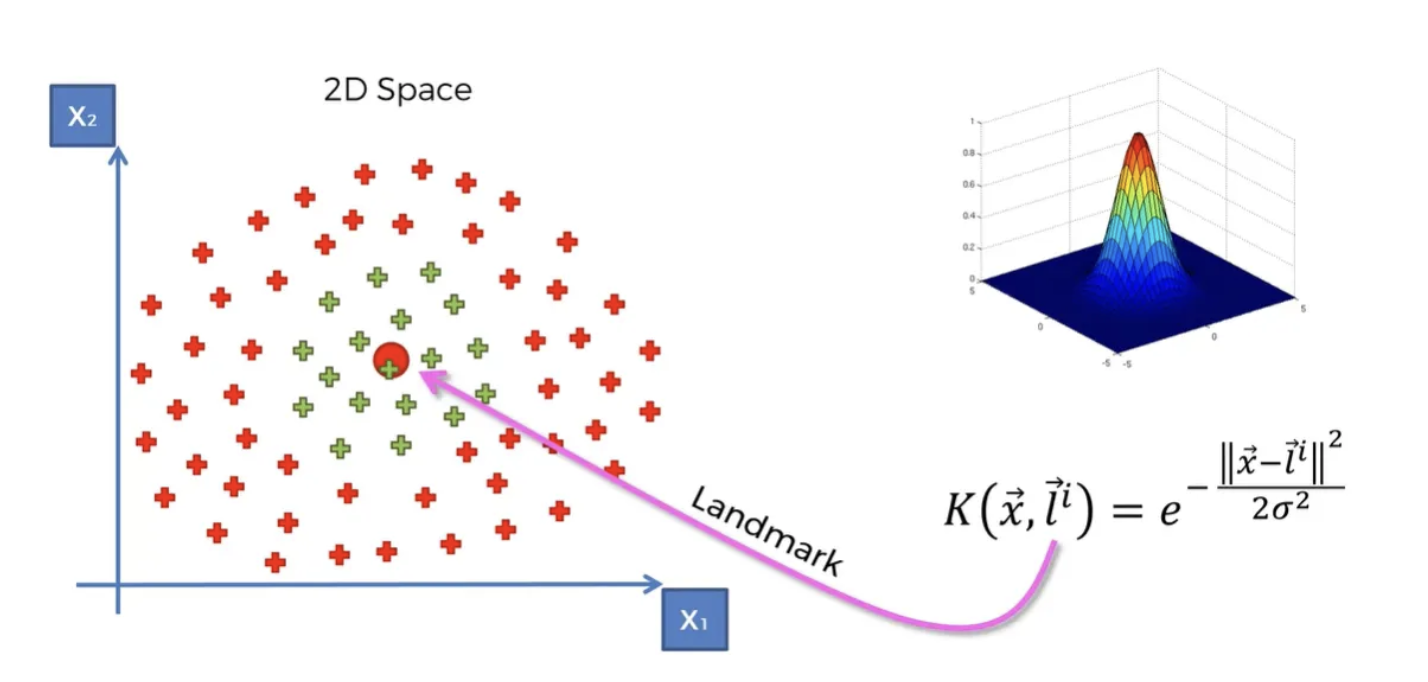

In [18]:
classifier=SVC(kernel='rbf')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[21  0]
 [ 0 19]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

1.0
